# Construção do dataset

### Imports

In [1]:
from os.path import join
from os import makedirs
from json import load, dump
from re import search

import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold
from tqdm.notebook import tqdm
from PIL import Image

import scripts.definitions as defs
import scripts.data as dt

### Processamento dos exames no JSON

In [2]:
with open(join(defs.DATA_PATH, 'stt_raw_data', 'dataset', 'dataset.json'), 'r', encoding='utf-8') as file:
    dataset = [dt.RawData(**data) for data in load(file)]

print(f'Número de exames: {len(dataset)}')

raw_lesion_dataset: dict[int, list[dt.RawLesionData]] = {}

for raw_data in tqdm(dataset, desc='Processando exames: '):
    approximation_series = list(filter(lambda series: search(r'LesÃ£o \d+.', series.seriesdescription),
                                       raw_data.series))

    if len(approximation_series) == 0:
        continue

    raw_lesion_dataset[raw_data.id_exame] = []

    for series in approximation_series:
        series_description = series.seriesdescription.split()
        lesion_location = ' '.join(series_description[3:]).encode('latin1').decode('utf-8')

        raw_lesion_data = dt.RawLesionData(
            exam_id=raw_data.id_exame,
            images=series.instances,
            lesion_number=int(series_description[1]),
            lesion_location=lesion_location,
            report=''
        )

        raw_lesion_dataset[raw_data.id_exame].append(raw_lesion_data)

print(f'Número de lesões de aproximação: {sum((len(lesions) for lesions in raw_lesion_dataset.values()))}')

Número de exames: 3651


Processando exames:   0%|          | 0/3651 [00:00<?, ?it/s]

Número de lesões de aproximação: 6880


### Processamento do CSV

In [3]:
df = pd.read_csv(join(defs.DATA_PATH, 'stt_raw_data', 'REDE_QUALIDADE-laudos-reemitidos.csv'))

print(f'Número de laudos: {len(df)}')

REPLACEMENTS = {
    '\\n': '\n',
    '<br />': '\n',
    '&emsp;': ' ',
    '&lt;': '<',
    '&gt;': '>',
    '–': '-',
}

raw_report_dataset = {}

for _, raw_report in tqdm(df.iterrows(), desc='Processando laudos: '):
    raw_report = dt.RawReport(**raw_report.to_dict())

    exam_id = int(raw_report.id_exame)

    if exam_id not in raw_lesion_dataset:
        continue

    report = raw_report.laudo

    for pattern, replacement in REPLACEMENTS.items():
        report = report.replace(pattern, replacement)

    raw_report_dataset[exam_id] = report

print(f'Número de laudos de lesões de aproximação: {len(raw_report_dataset)}')

Número de laudos: 3651


Processando laudos: : 0it [00:00, ?it/s]

Número de laudos de lesões de aproximação: 3651


### Geração dos laudos estruturados

In [4]:
reports = {}
total_reports = 0

for exam_id, raw_report in tqdm(raw_report_dataset.items(), desc='Estruturando laudos: '):
    # O [1:] remove o tipo de laudo. Sempre é "Exame de Teledermatologia"
    report_parts = list(map(str.strip, raw_report.splitlines()))[1:]

    parsed_reports = []
    footnotes = {}

    while True:
        report, has_next = dt.parse_report(report_parts)

        if not has_next:
            footnotes = dt.parse_report_footnote(report_parts)
            break

        parsed_reports.append(report)

    total_reports += len(parsed_reports)

    locations: dict[str, list[dt.Report]] = {}

    for parsed_report in parsed_reports:
        if parsed_report.location not in locations:
            locations[parsed_report.location] = []

        locations[parsed_report.location].append(parsed_report)

    # Remove laudos com informações conflitantes para mesma parte do corpo
    for location, reports in locations.items():
        valid = True
        reference_report = reports[0]

        for report in reports[1:]:
            if report.elementary_lesions != reference_report.elementary_lesions or \
               report.secondary_lesions != reference_report.secondary_lesions or \
               report.coloration != reference_report.coloration or \
               report.morphology != reference_report.morphology or \
               report.size != reference_report.size or \
               report.distribution != reference_report.distribution or \
               report.risk != reference_report.risk or \
               report.skin_lesion != reference_report.skin_lesion:
                valid = False
                break

        if not valid:
            for report in reports:
                parsed_reports.remove(report)
            continue

    for raw_lesion_data in raw_lesion_dataset[exam_id]:
        index = 0

        while index < len(parsed_reports):
            report = parsed_reports[index]

            if raw_lesion_data.lesion_location == report.location:
                if raw_lesion_data.report != '':
                    raise ValueError('Conflito de laudos')

                raw_lesion_data.report = parsed_reports.pop(index)
                break

            index += 1

        if raw_lesion_data.report != '':
            lesion_number = raw_lesion_data.lesion_number
            footnote = footnotes.get(lesion_number, None)

            if footnote is not None:
                raw_lesion_data.report.skin_lesion_conclusion += footnote  # type: ignore

print(f'Número de laudos de lesões: {total_reports}')

dataset: list[dt.LesionData] = []

total_lesions = 0

for exam_id, raw_lesion_datalist in raw_lesion_dataset.items():
    for raw_lesion_data in raw_lesion_datalist:
        if raw_lesion_data.report != '':
            total_lesions += 1

            for image in raw_lesion_data.images:
                lesion_data = dt.LesionData(exam_id=exam_id, image=image, report=raw_lesion_data.report)  # type: ignore
                dataset.append(lesion_data)

print(f'Número de pares de imagens e laudos: {len(dataset)}')

approximation_exams_dicts = [approximation_exam.model_dump() for approximation_exam in dataset]
dataset_name = 'dataset.json'

makedirs(join(defs.DATA_PATH, 'stt_data'), exist_ok=True)

with open(join(defs.DATA_PATH, 'stt_data', dataset_name), 'w', encoding='utf-8') as file:
    dump(approximation_exams_dicts, file, indent=4, ensure_ascii=False)

data_analysis = dt.analyse_dataset(dataset, defs.DATA_PATH, dataset_name)

Estruturando laudos:   0%|          | 0/3651 [00:00<?, ?it/s]

Número de laudos de lesões: 5885
Número de pares de imagens e laudos: 5988


### Processamento das imagens

In [ ]:
makedirs(join(defs.DATA_PATH, 'stt_data', 'images'), exist_ok=True)

for data in tqdm(dataset, desc='Processando imagens: '):
    image_path = join(defs.DATA_PATH, 'stt_raw_data', 'dataset', 'images', data.image)
    image = Image.open(image_path)
    image = image.convert('RGB')

    largest_side = max(image.size)

    if largest_side > defs.MAX_IMAGE_SIZE:
        scale = defs.MAX_IMAGE_SIZE / largest_side
        new_size = tuple(int(dimension * scale) for dimension in image.size)
        image = image.resize(new_size)  # type: ignore

    image.save(join(defs.DATA_PATH, 'stt_data', 'images', data.image), format='JPEG', quality=100)

### Remoção de lesões raras e de dados desnecessários

Número de pares de imagens e laudos após filtragem: 5903


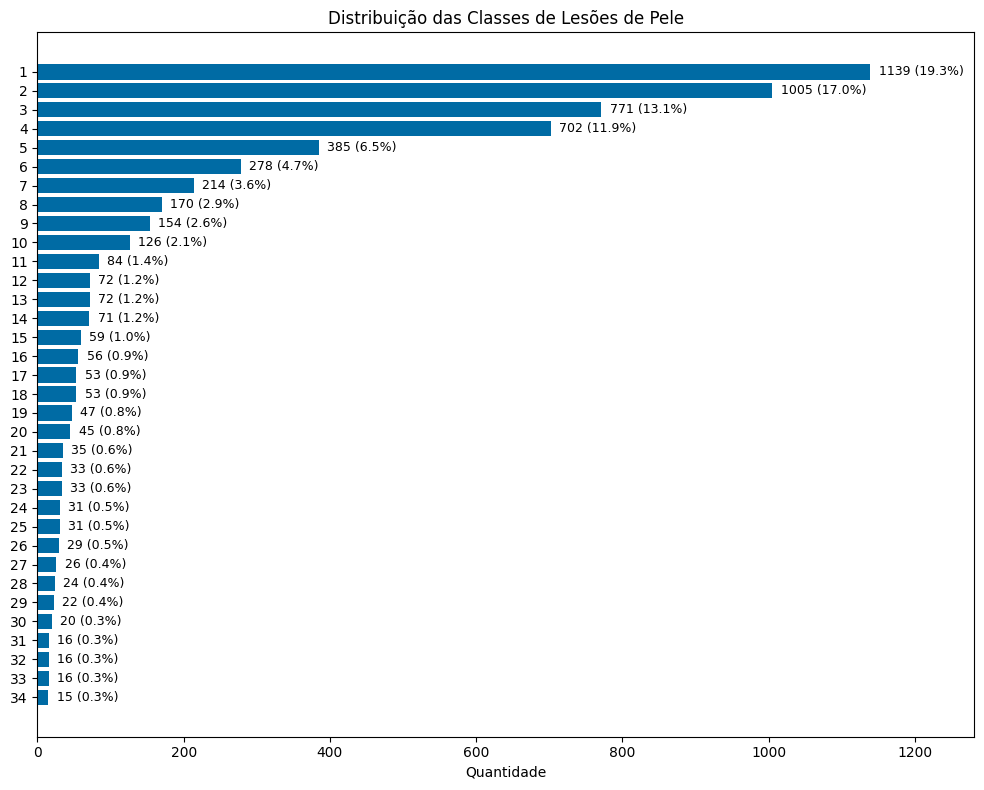

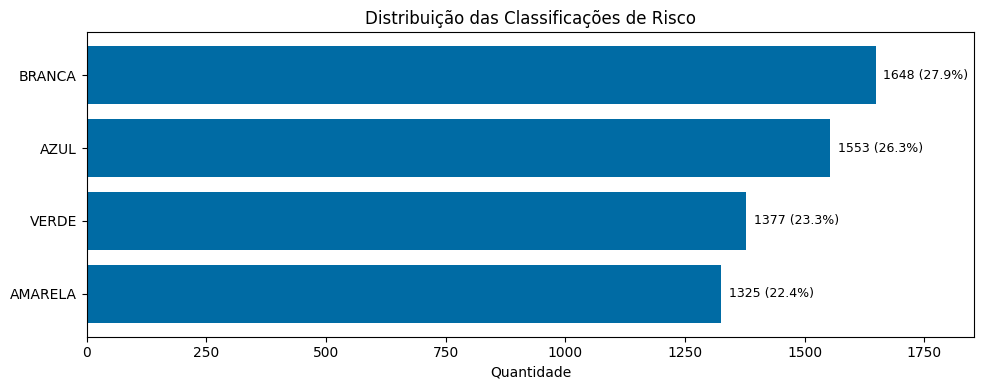

In [5]:
dataset = list(filter(lambda data: data_analysis.skin_lesion_distribution.classes[data.report.skin_lesion].count >= 15,
                      dataset))

print(f'Número de pares de imagens e laudos após filtragem: {len(dataset)}')

simple_dataset = []

for data in dataset:
    simple_report = dt.SimpleReport(
        skin_lesion=data.report.skin_lesion,
        risk=data.report.risk,
        conclusion=data.report.conclusion,
        skin_lesion_conclusion=data.report.skin_lesion_conclusion,
    )

    simple_lesion_data = dt.SimpleLesionData(
        exam_id=data.exam_id,
        image=data.image,
        report=simple_report
    )

    simple_dataset.append(simple_lesion_data)

dataset = simple_dataset

data_dicts = [data.model_dump() for data in dataset]
dataset_name = 'simple_dataset.json'

with open(join(defs.DATA_PATH, 'stt_data', dataset_name), 'w', encoding='utf-8') as file:
    dump(data_dicts, file, indent=4, ensure_ascii=False)

simple_dataset_analysis = dt.analyse_simple_dataset(simple_dataset, defs.DATA_PATH, dataset_name)

dt.plot_skin_lesion_distribution(simple_dataset_analysis)
dt.plot_risk_distribution(simple_dataset_analysis)

### Seccionamento dos dados

Número de pares de imagens e laudos de treinamento: 4736
Número de pares de imagens e laudos de teste: 1167


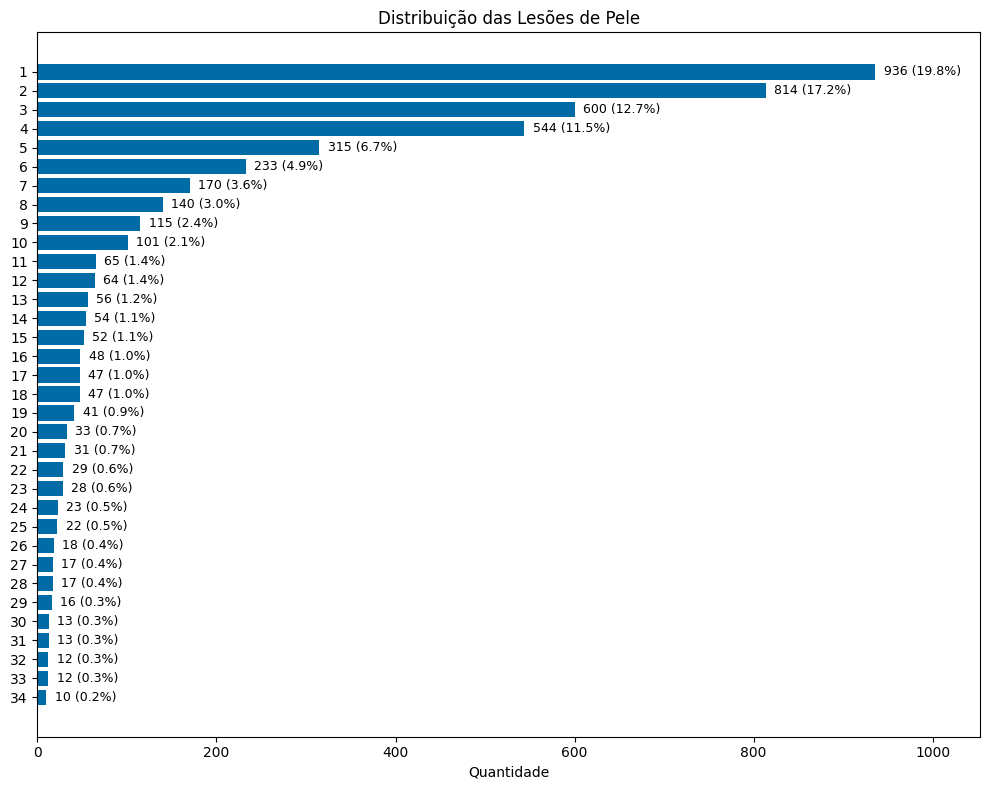

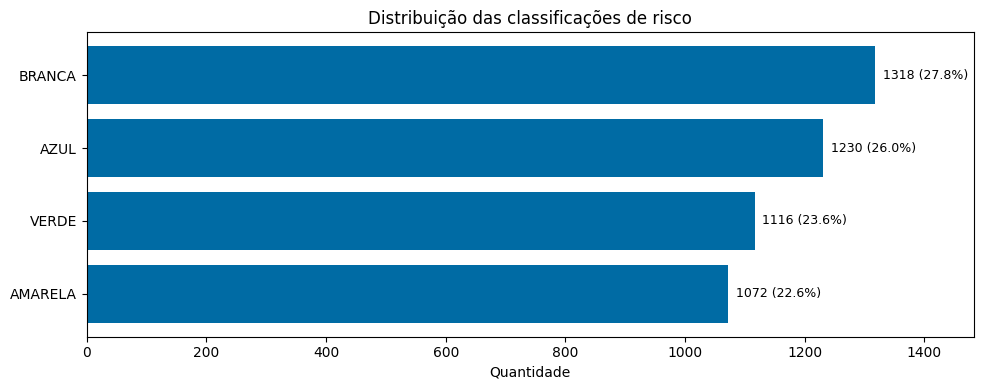

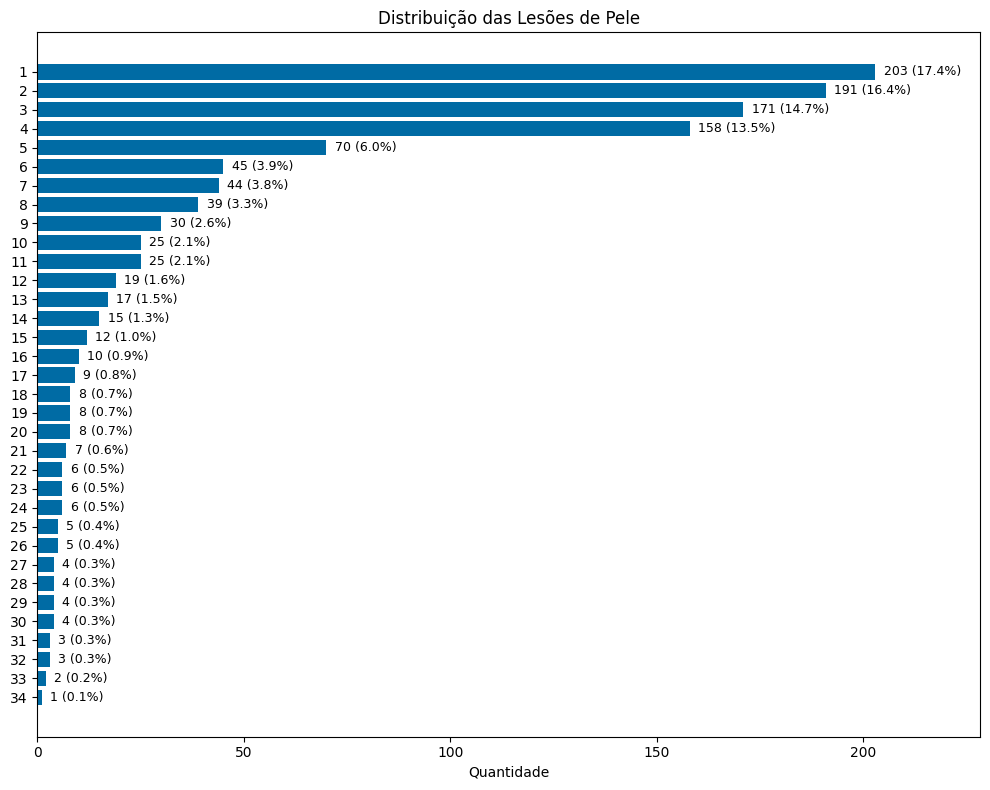

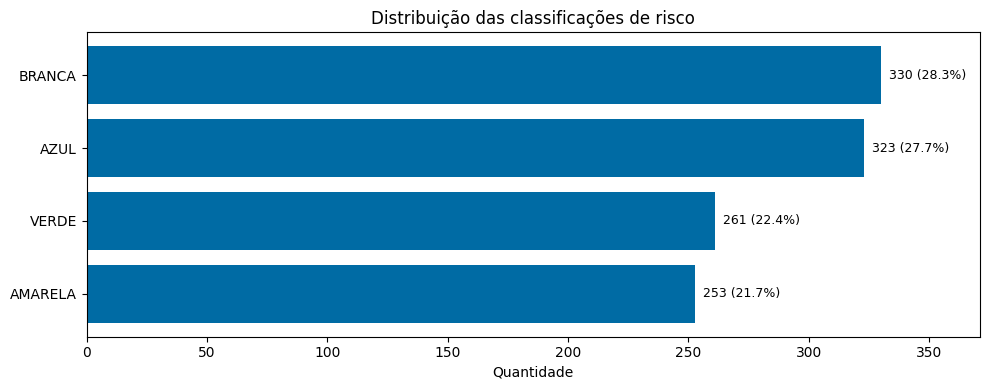

In [6]:
exams = [data.exam_id for data in dataset]
labels = [data.report.skin_lesion for data in simple_dataset]

stratified_group_kfold = StratifiedGroupKFold(n_splits=int(1.0 / defs.TEST_PROPORTION),
                                              shuffle=True,
                                              random_state=defs.STATIC_RANDOM_STATE)

training_indices, test_indices = next(stratified_group_kfold.split(simple_dataset, labels, exams))

training_data = [simple_dataset[i] for i in training_indices]
test_data = [simple_dataset[i] for i in test_indices]

print(f'Número de pares de imagens e laudos de treinamento: {len(training_data)}')
print(f'Número de pares de imagens e laudos de teste: {len(test_data)}')

training_labels = [data.report.skin_lesion for data in training_data]

dataset_pairs = ((training_data, 'training_dataset.json'),
                 (test_data, 'test_dataset.json'))

for dataset, dataset_name in dataset_pairs:
    dataset_dict = [data.model_dump() for data in dataset]

    with open(join(defs.DATA_PATH, 'stt_data', dataset_name), 'w', encoding='utf-8') as file:
        dump(dataset_dict, file, indent=4, ensure_ascii=False)

    simple_dataset_analysis = dt.analyse_simple_dataset(dataset, defs.DATA_PATH, dataset_name)

    dt.plot_skin_lesion_distribution(simple_dataset_analysis)
    dt.plot_risk_distribution(simple_dataset_analysis)